# Assignment-6: Denoising Autoencoder (DAE)

## Objective
Design, train, and evaluate a Denoising Autoencoder to reconstruct clean images from corrupted inputs. This assignment explores:
- Different types of noise (Gaussian and salt-and-pepper)
- Impact of noise levels on reconstruction quality
- Effect of encoder architectures and upsampling techniques
- Strategies for handling limited annotated data

## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import seaborn as sns
from skimage import metrics, util
from scipy.ndimage import maximum_filter
import warnings

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check GPU availability
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU'))} device(s)")
if tf.config.list_physical_devices('GPU'):
    print(f"Using GPU: {tf.config.list_physical_devices('GPU')[0]}")
else:
    print("Using CPU")

I0000 00:00:1777829547.428914    1700 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU Available: 1 device(s)
Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 2. Load and Preprocess CIFAR-10 Dataset

Training data shape: (10000, 32, 32, 3)
Test data shape: (2000, 32, 32, 3)
Pixel value range: [0.0, 1.0]


I0000 00:00:1777829557.807490    1700 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1753 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


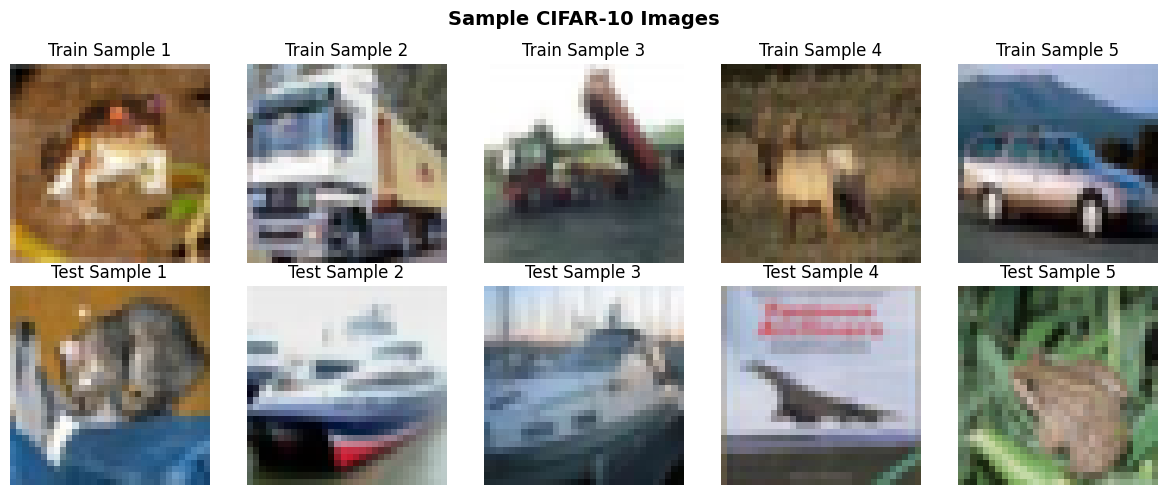

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize images to [0, 1] range
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Use a subset for faster training
train_size = 10000  # Reduced for faster training
test_size = 2000
x_train = x_train[:train_size]
y_train = y_train[:train_size]
x_test = x_test[:test_size]
y_test = y_test[:test_size]

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Pixel value range: [{x_train.min()}, {x_train.max()}]")

# Create data loaders
batch_size = 128
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(len(x_train)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices(x_test).batch(batch_size)

# Visualization of sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample CIFAR-10 Images', fontsize=14, fontweight='bold')
for i in range(5):
    axes[0, i].imshow(x_train[i])
    axes[0, i].set_title(f'Train Sample {i+1}')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_test[i])
    axes[1, i].set_title(f'Test Sample {i+1}')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## 3. Implement Noise Functions

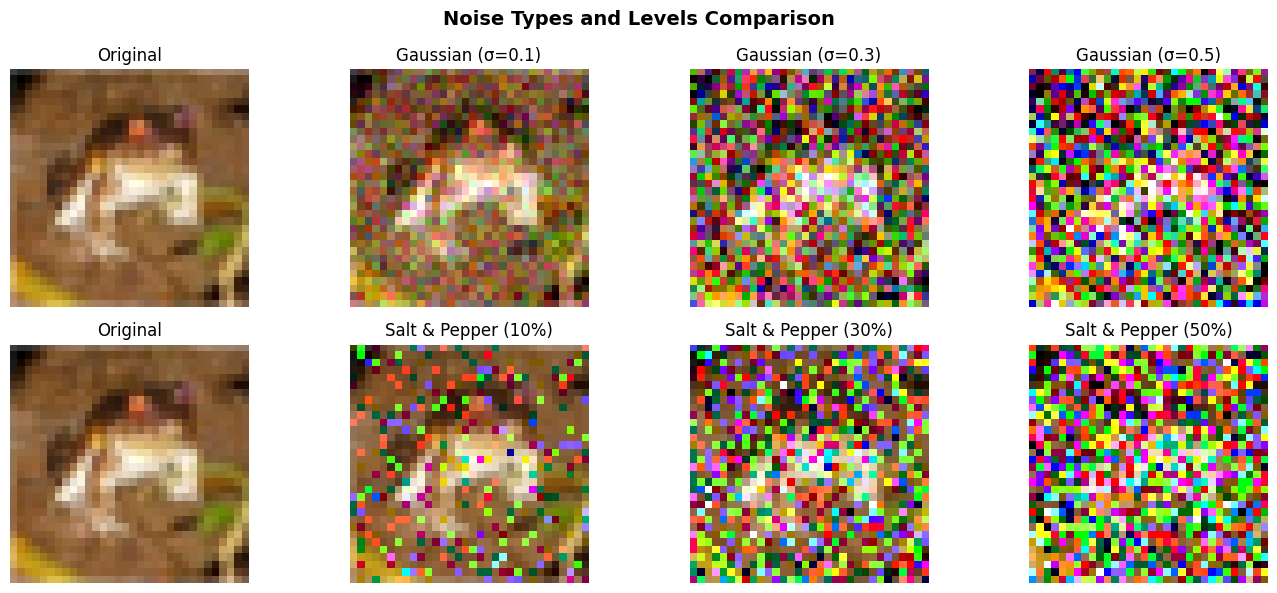

In [3]:
def add_gaussian_noise(images, noise_level=0.1):
    """
    Add Gaussian noise to images.
    
    Args:
        images: Input images (numpy array or tensor)
        noise_level: Standard deviation of Gaussian noise
    
    Returns:
        Noisy images with clipped values to [0, 1]
    """
    noise = np.random.normal(0, noise_level, images.shape)
    noisy = images + noise
    return np.clip(noisy, 0, 1)

def add_salt_pepper_noise(images, noise_level=0.1):
    """
    Add salt-and-pepper noise to images.
    
    Args:
        images: Input images (numpy array or tensor)
        noise_level: Fraction of pixels to corrupt (0.0 to 1.0)
    
    Returns:
        Noisy images with salt-and-pepper noise
    """
    noisy = images.copy()
    num_pixels = images.size
    num_noisy = int(num_pixels * noise_level)
    
    # Randomly select pixels to corrupt
    coords = np.random.choice(num_pixels, num_noisy, replace=False)
    
    for coord in coords:
        # Randomly set to either 0 (pepper) or 1 (salt)
        noisy.flat[coord] = np.random.choice([0, 1])
    
    return noisy

# Test noise functions
test_image = x_train[:1]  # Single image

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Noise Types and Levels Comparison', fontsize=14, fontweight='bold')

noise_levels = [0.1, 0.3, 0.5]

# Gaussian noise
axes[0, 0].imshow(test_image[0])
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

for i, level in enumerate(noise_levels):
    noisy_gaussian = add_gaussian_noise(test_image, level)
    axes[0, i+1].imshow(noisy_gaussian[0])
    axes[0, i+1].set_title(f'Gaussian (σ={level})')
    axes[0, i+1].axis('off')

# Salt-and-pepper noise
axes[1, 0].imshow(test_image[0])
axes[1, 0].set_title('Original')
axes[1, 0].axis('off')

for i, level in enumerate(noise_levels):
    noisy_sp = add_salt_pepper_noise(test_image, level)
    axes[1, i+1].imshow(noisy_sp[0])
    axes[1, i+1].set_title(f'Salt & Pepper ({level*100:.0f}%)')
    axes[1, i+1].axis('off')

plt.tight_layout()
plt.show()

## 4. Build Denoising Autoencoder Architectures

### 4.1 DAE with Transposed Convolution Upsampling

In [4]:
def build_dae_transposed_conv(input_shape=(32, 32, 3)):
    """
    Build DAE with transposed convolution for upsampling.
    """
    model = models.Sequential([
        # Encoder
        layers.Input(shape=input_shape),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2), padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2), padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2), padding='same'),
        
        # Decoder with Transposed Convolution
        layers.Conv2DTranspose(256, (3, 3), activation='relu', padding='same'),
        layers.UpSampling2D((2, 2)),
        layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same'),
        layers.UpSampling2D((2, 2)),
        layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same'),
        layers.UpSampling2D((2, 2)),
        
        # Output layer
        layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')
    ])
    
    return model

# Build and display model
dae_transposed = build_dae_transposed_conv()
dae_transposed.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 4, 4, 256)      │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 8, 8, 128)      │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,459 (5.08 MB)

 Trainable params: 1,331,459 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

### 4.2 DAE with Max Unpooling (UpSampling2D)

In [5]:
def build_dae_upsampling(input_shape=(32, 32, 3)):
    """
    Build DAE with UpSampling2D (similar to max unpooling).
    """
    model = models.Sequential([
        # Encoder
        layers.Input(shape=input_shape),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2), padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2), padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2), padding='same'),
        
        # Decoder with UpSampling2D
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.UpSampling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.UpSampling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.UpSampling2D((2, 2)),
        
        # Output layer
        layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')
    ])
    
    return model

# Build and display model
dae_upsampling = build_dae_upsampling()
dae_upsampling.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,459 (5.08 MB)

 Trainable params: 1,331,459 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

### 4.3 DAE with Skip Connections

In [6]:
def build_dae_skip_connections(input_shape=(32, 32, 3)):
    """
    Build DAE with skip connections for better gradient flow and feature preservation.
    """
    inputs = layers.Input(shape=input_shape)
    
    # Encoder
    enc1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    pool1 = layers.MaxPooling2D((2, 2), padding='same')(enc1)
    
    enc2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    pool2 = layers.MaxPooling2D((2, 2), padding='same')(enc2)
    
    enc3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    pool3 = layers.MaxPooling2D((2, 2), padding='same')(enc3)
    
    # Bottleneck
    bottleneck = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    
    # Decoder with skip connections
    up1 = layers.UpSampling2D((2, 2))(bottleneck)
    concat1 = layers.Concatenate()([up1, enc3])
    dec1 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(concat1)
    
    up2 = layers.UpSampling2D((2, 2))(dec1)
    concat2 = layers.Concatenate()([up2, enc2])
    dec2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(concat2)
    
    up3 = layers.UpSampling2D((2, 2))(dec2)
    concat3 = layers.Concatenate()([up3, enc1])
    dec3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(concat3)
    
    # Output layer
    outputs = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(dec3)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Build and display model
dae_skip = build_dae_skip_connections()
dae_skip.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │      1,792 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ conv2d_11[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_6[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 8, 8, 128) │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 4, 4, 256) │          0 │ conv2d_13[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 4, 4, 256) │    590,080 │ max_pooling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_6     │ (None, 8, 8, 256) │          0 │ conv2d_14[0][0]   │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8, 512) │          0 │ up_sampling2d_6[… │
│ (Concatenate)       │                   │            │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 8, 8, 256) │  1,179,904 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_7     │ (None, 16, 16,    │          0 │ conv2d_15[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ up_sampling2d_7[… │
│ (Concatenate)       │ 384)              │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 16, 16,    │    442,496 │ concatenate_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_8     │ (None, 32, 32,    │          0 │ conv2d_16[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 32, 32,    │          0 │ up_sampling2d_8[… │
│ (Concatenate)       │ 192)              │            │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 32,    │    110,656 │ concatenate_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 32, 32, 3) │      1,731 │ conv2d_17[0][0] 

 Total params: 2,695,683 (10.28 MB)

 Trainable params: 2,695,683 (10.28 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Denoising Autoencoder

In [7]:
# Prepare noisy training data
noise_level = 0.2
x_train_noisy_gaussian = add_gaussian_noise(x_train, noise_level)
x_test_noisy_gaussian = add_gaussian_noise(x_test, noise_level)

# Create datasets with noisy inputs and clean targets
train_noisy_ds = tf.data.Dataset.from_tensor_slices((x_train_noisy_gaussian, x_train)).shuffle(len(x_train)).batch(batch_size)
test_noisy_ds = tf.data.Dataset.from_tensor_slices((x_test_noisy_gaussian, x_test)).batch(batch_size)

# Compile models
for model in [dae_transposed, dae_upsampling, dae_skip]:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

# Train models
epochs = 20
histories = {}
model_names = ['TransposedConv', 'UpSampling2D', 'SkipConnections']
models = [dae_transposed, dae_upsampling, dae_skip]

for model, model_name in zip(models, model_names):
    print(f"\n{'='*50}")
    print(f"Training {model_name}...")
    print(f"{'='*50}")
    
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    history = model.fit(
        train_noisy_ds,
        validation_data=test_noisy_ds,
        epochs=epochs,
        callbacks=[early_stop],
        verbose=1
    )
    
    histories[model_name] = history

print("\nTraining completed!")


Training TransposedConv...
Epoch 1/20


I0000 00:00:1777829571.832624   40213 service.cc:153] XLA service 0x73c650036510 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777829571.832703   40213 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6 (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.17.1)
I0000 00:00:1777829566.641242   40213 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777829566.982774   40213 cuda_dnn.cc:461] Loaded cuDNN version 91701


 2/79 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0628 - mae: 0.2087  

I0000 00:00:1777829578.434769   40213 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 184ms/step - loss: 0.0339 - mae: 0.1434 - val_loss: 0.0198 - val_mae: 0.1070
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0162 - mae: 0.0953 - val_loss: 0.0139 - val_mae: 0.0875
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0133 - mae: 0.0854 - val_loss: 0.0122 - val_mae: 0.0814
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.0116 - mae: 0.0791 - val_loss: 0.0111 - val_mae: 0.0769
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0109 - mae: 0.0763 - val_loss: 0.0109 - val_mae: 0.0766
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0102 - mae: 0.0736 - val_loss: 0.0102 - val_mae: 0.0737
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0095 - mae: 0.0709 - val_loss: 0.0099 - val_mae: 0.0731
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0091 - mae: 0.0696 - val_loss: 0.0089 - val_mae: 0.0688
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0087 - mae: 

W0000 00:00:1777829706.535483   40212 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.16GiB (rounded to 1246151168)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1777829706.535593   40212 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1777829706.535602   40212 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 102, Chunks in use: 102. 25.5KiB allocated for chunks. 25.5KiB in use in bin. 4.2KiB client-requested in use in bin.
I0000 00:00:1777829706.535611   40212 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 15, Chunks in use: 15. 7.5KiB allocated for chunks. 7.5KiB in use in bin. 7.5KiB client-requested in use in bin.
I0000 00:00:1777829706.535614   40212 bfc_allocator.cc:1056] Bin (1024): 	Total Chunks: 17, Chunks in use: 17. 18.2KiB allocated f

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0325 - mae: 0.1388

W0000 00:00:1777829752.004140   40211 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 952.00MiB (rounded to 998244864)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1777829752.004340   40211 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1777829752.004353   40211 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 113, Chunks in use: 112. 28.2KiB allocated for chunks. 28.0KiB in use in bin. 5.0KiB client-requested in use in bin.
I0000 00:00:1777829752.004362   40211 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 19, Chunks in use: 18. 9.8KiB allocated for chunks. 9.0KiB in use in bin. 9.0KiB client-requested in use in bin.
I0000 00:00:1777829752.004368   40211 bfc_allocator.cc:1056] Bin (1024): 	Total Chunks: 23, Chunks in use: 22. 24.8KiB allocated 

79/79 ━━━━━━━━━━━━━━━━━━━━ 75s 523ms/step - loss: 0.0180 - mae: 0.0987 - val_loss: 0.0062 - val_mae: 0.0616
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0054 - mae: 0.0569 - val_loss: 0.0068 - val_mae: 0.0656
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0049 - mae: 0.0543 - val_loss: 0.0051 - val_mae: 0.0553
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0047 - mae: 0.0532 - val_loss: 0.0053 - val_mae: 0.0566
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0045 - mae: 0.0520 - val_loss: 0.0044 - val_mae: 0.0513
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0044 - mae: 0.0510 - val_loss: 0.0044 - val_mae: 0.0509
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0043 - mae: 0.0502 - val_loss: 0.0044 - val_mae: 0.0507
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0042 - mae: 0.0496 - val_loss: 0.0042 - val_mae: 0.0499
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0041 - mae: 

## 6. Evaluate Reconstruction Loss and Metrics

In [10]:

import pandas as pd
def calculate_psnr(original, reconstructed):
    """
    Calculate Peak Signal-to-Noise Ratio (PSNR).
    Higher is better (typical range: 20-50 dB).
    """
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

def calculate_ssim(original, reconstructed):
    """
    Calculate Structural Similarity Index (SSIM).
    Range: -1 to 1 (higher is better, typically > 0.9 is good).
    """
    ssim_values = []
    for i in range(len(original)):
        ssim = metrics.structural_similarity(original[i], reconstructed[i], channel_axis=2, data_range=1.0)
        ssim_values.append(ssim)
    return np.mean(ssim_values)

# Evaluate all models
predictions = {}
evaluation_metrics = {}

for model, model_name in zip(models, model_names):
    print(f"\nEvaluating {model_name}...")
    
    # Make predictions
    predictions[model_name] = model.predict(x_test_noisy_gaussian, verbose=0)
    
    # Calculate metrics
    mse = np.mean((x_test - predictions[model_name]) ** 2)
    psnr = calculate_psnr(x_test, predictions[model_name])
    ssim = calculate_ssim(x_test, predictions[model_name])
    
    # MSE of noisy input vs clean target
    mse_noisy = np.mean((x_test - x_test_noisy_gaussian) ** 2)
    
    evaluation_metrics[model_name] = {
        'MSE': mse,
        'PSNR': psnr,
        'SSIM': ssim,
        'MSE_Noisy_Input': mse_noisy
    }
    
    print(f"  MSE: {mse:.6f}")
    print(f"  PSNR: {psnr:.2f} dB")
    print(f"  SSIM: {ssim:.4f}")
    print(f"  MSE (Noisy Input vs Clean): {mse_noisy:.6f}")

# Display comparison
print("\n" + "="*80)
print("RECONSTRUCTION QUALITY COMPARISON")
print("="*80)

metrics_df = pd.DataFrame(evaluation_metrics).T
print(metrics_df.round(6))



Evaluating TransposedConv...
  MSE: 0.006907
  PSNR: 21.61 dB
  SSIM: 0.7070
  MSE (Noisy Input vs Clean): 0.033277

Evaluating UpSampling2D...
  MSE: 0.006905
  PSNR: 21.61 dB
  SSIM: 0.7064
  MSE (Noisy Input vs Clean): 0.033277

Evaluating SkipConnections...
  MSE: 0.003697
  PSNR: 24.32 dB
  SSIM: 0.8235
  MSE (Noisy Input vs Clean): 0.033277

RECONSTRUCTION QUALITY COMPARISON
                      MSE       PSNR      SSIM  MSE_Noisy_Input
TransposedConv   0.006907  21.607180  0.707001         0.033277
UpSampling2D     0.006905  21.608458  0.706425         0.033277
SkipConnections  0.003697  24.321098  0.823514         0.033277


## 7. Visualize Denoised Outputs

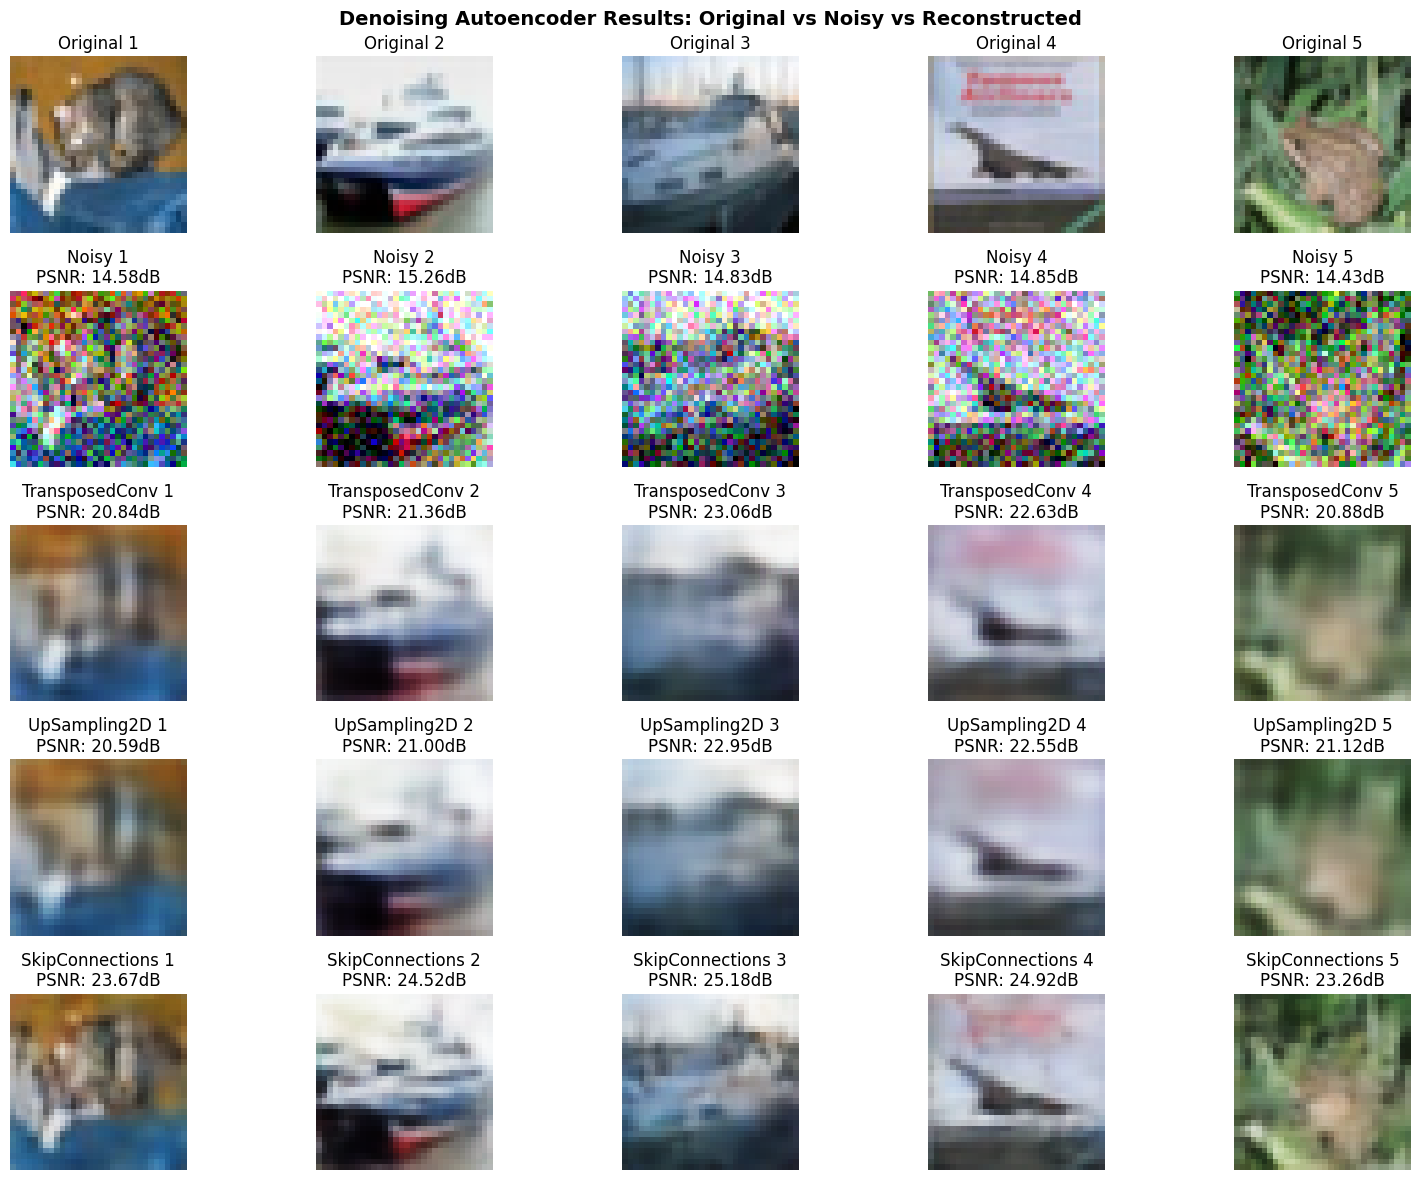

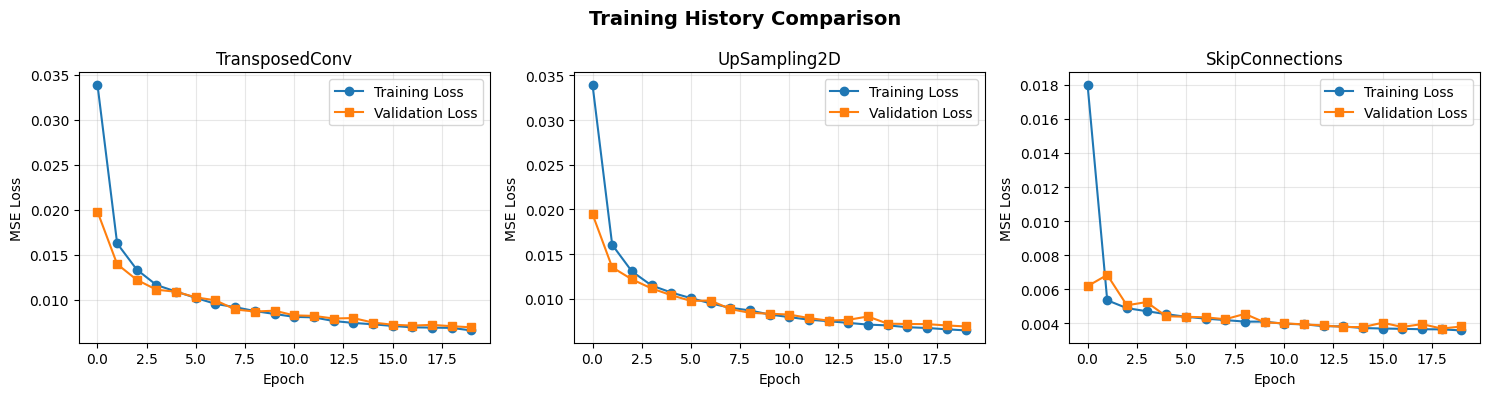

In [11]:
# Visualize reconstructions for each model
n_samples = 5
fig, axes = plt.subplots(len(model_names) + 2, n_samples, figsize=(16, 12))
fig.suptitle('Denoising Autoencoder Results: Original vs Noisy vs Reconstructed', fontsize=14, fontweight='bold')

# Original clean images
for i in range(n_samples):
    axes[0, i].imshow(x_test[i])
    axes[0, i].set_title(f'Original {i+1}')
    axes[0, i].axis('off')

# Noisy images
for i in range(n_samples):
    axes[1, i].imshow(x_test_noisy_gaussian[i])
    axes[1, i].set_title(f'Noisy {i+1}\nPSNR: {calculate_psnr(x_test[i:i+1], x_test_noisy_gaussian[i:i+1]):.2f}dB')
    axes[1, i].axis('off')

# Reconstructed images for each model
for row, (model_name, prediction) in enumerate(predictions.items()):
    for i in range(n_samples):
        psnr_val = calculate_psnr(x_test[i:i+1], prediction[i:i+1])
        axes[row + 2, i].imshow(prediction[i])
        axes[row + 2, i].set_title(f'{model_name} {i+1}\nPSNR: {psnr_val:.2f}dB')
        axes[row + 2, i].axis('off')

plt.tight_layout()
plt.show()

# Visualize training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training History Comparison', fontsize=14, fontweight='bold')

for idx, model_name in enumerate(model_names):
    history = histories[model_name]
    axes[idx].plot(history.history['loss'], label='Training Loss', marker='o')
    axes[idx].plot(history.history['val_loss'], label='Validation Loss', marker='s')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('MSE Loss')
    axes[idx].set_title(f'{model_name}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Analyze Noise Level Effects

Analyzing effect of noise levels...

Processing noise level: 0.05

Processing noise level: 0.10

Processing noise level: 0.15

Processing noise level: 0.20

Processing noise level: 0.30

Processing noise level: 0.40


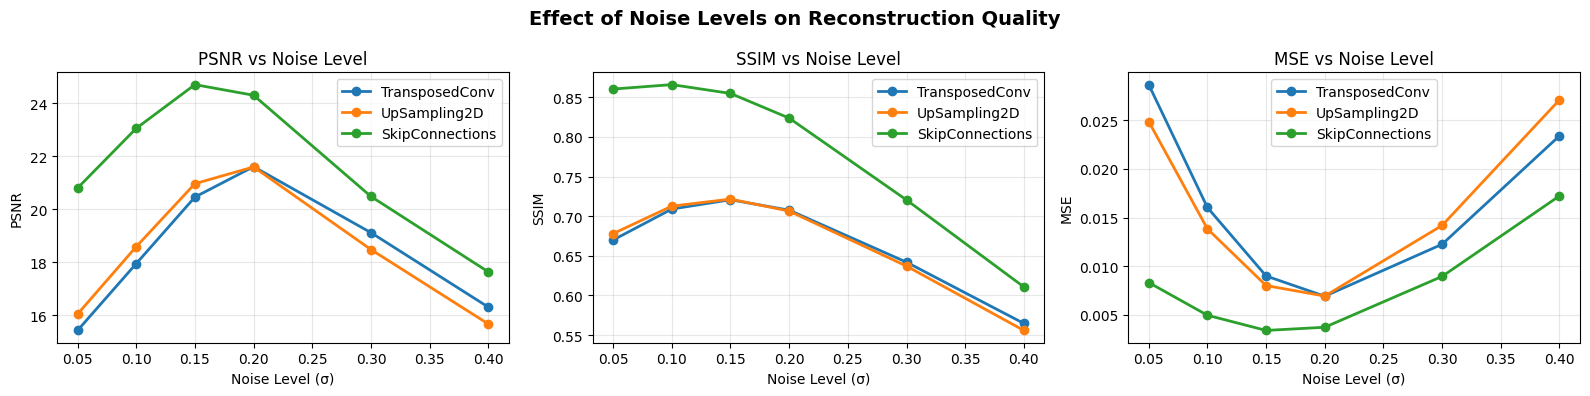


NOISE LEVEL ANALYSIS SUMMARY

TransposedConv:
  PSNR Range: 15.42 - 21.61 dB
  SSIM Range: 0.5647 - 0.7207
  MSE Range: 0.006900 - 0.028688

UpSampling2D:
  PSNR Range: 15.67 - 21.60 dB
  SSIM Range: 0.5559 - 0.7215
  MSE Range: 0.006915 - 0.027116

SkipConnections:
  PSNR Range: 17.64 - 24.71 dB
  SSIM Range: 0.6107 - 0.8659
  MSE Range: 0.003379 - 0.017230


In [12]:
# Analyze effect of different noise levels
noise_levels = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4]
noise_analysis = {model_name: {'noise_levels': [], 'psnr': [], 'ssim': [], 'mse': []} for model_name in model_names}

print("Analyzing effect of noise levels...")
for noise_level in noise_levels:
    print(f"\nProcessing noise level: {noise_level:.2f}")
    
    # Create noisy test data
    x_test_noisy = add_gaussian_noise(x_test, noise_level)
    
    for model, model_name in zip(models, model_names):
        # Reconstruct
        reconstructed = model.predict(x_test_noisy, verbose=0)
        
        # Calculate metrics
        psnr = calculate_psnr(x_test, reconstructed)
        ssim = calculate_ssim(x_test, reconstructed)
        mse = np.mean((x_test - reconstructed) ** 2)
        
        noise_analysis[model_name]['noise_levels'].append(noise_level)
        noise_analysis[model_name]['psnr'].append(psnr)
        noise_analysis[model_name]['ssim'].append(ssim)
        noise_analysis[model_name]['mse'].append(mse)

# Plot noise level analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Effect of Noise Levels on Reconstruction Quality', fontsize=14, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(['psnr', 'ssim', 'mse']):
    for model_idx, model_name in enumerate(model_names):
        axes[idx].plot(
            noise_analysis[model_name]['noise_levels'],
            noise_analysis[model_name][metric],
            marker='o',
            label=model_name,
            color=colors[model_idx],
            linewidth=2
        )
    
    axes[idx].set_xlabel('Noise Level (σ)')
    axes[idx].set_ylabel(metric.upper())
    axes[idx].set_title(f'{metric.upper()} vs Noise Level')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*80)
print("NOISE LEVEL ANALYSIS SUMMARY")
print("="*80)
for model_name in model_names:
    print(f"\n{model_name}:")
    print(f"  PSNR Range: {min(noise_analysis[model_name]['psnr']):.2f} - {max(noise_analysis[model_name]['psnr']):.2f} dB")
    print(f"  SSIM Range: {min(noise_analysis[model_name]['ssim']):.4f} - {max(noise_analysis[model_name]['ssim']):.4f}")
    print(f"  MSE Range: {min(noise_analysis[model_name]['mse']):.6f} - {max(noise_analysis[model_name]['mse']):.6f}")

## 9. Compare Upsampling Techniques

### Analysis of Transposed Convolution vs UpSampling2D


UPSAMPLING TECHNIQUES COMPARISON
             Technique  Parameters      PSNR     SSIM      MSE
Transposed Convolution     1331459 21.607180 0.707001 0.006907
          UpSampling2D     1331459 21.608458 0.706425 0.006905
      Skip Connections     2695683 24.321098 0.823514 0.003697


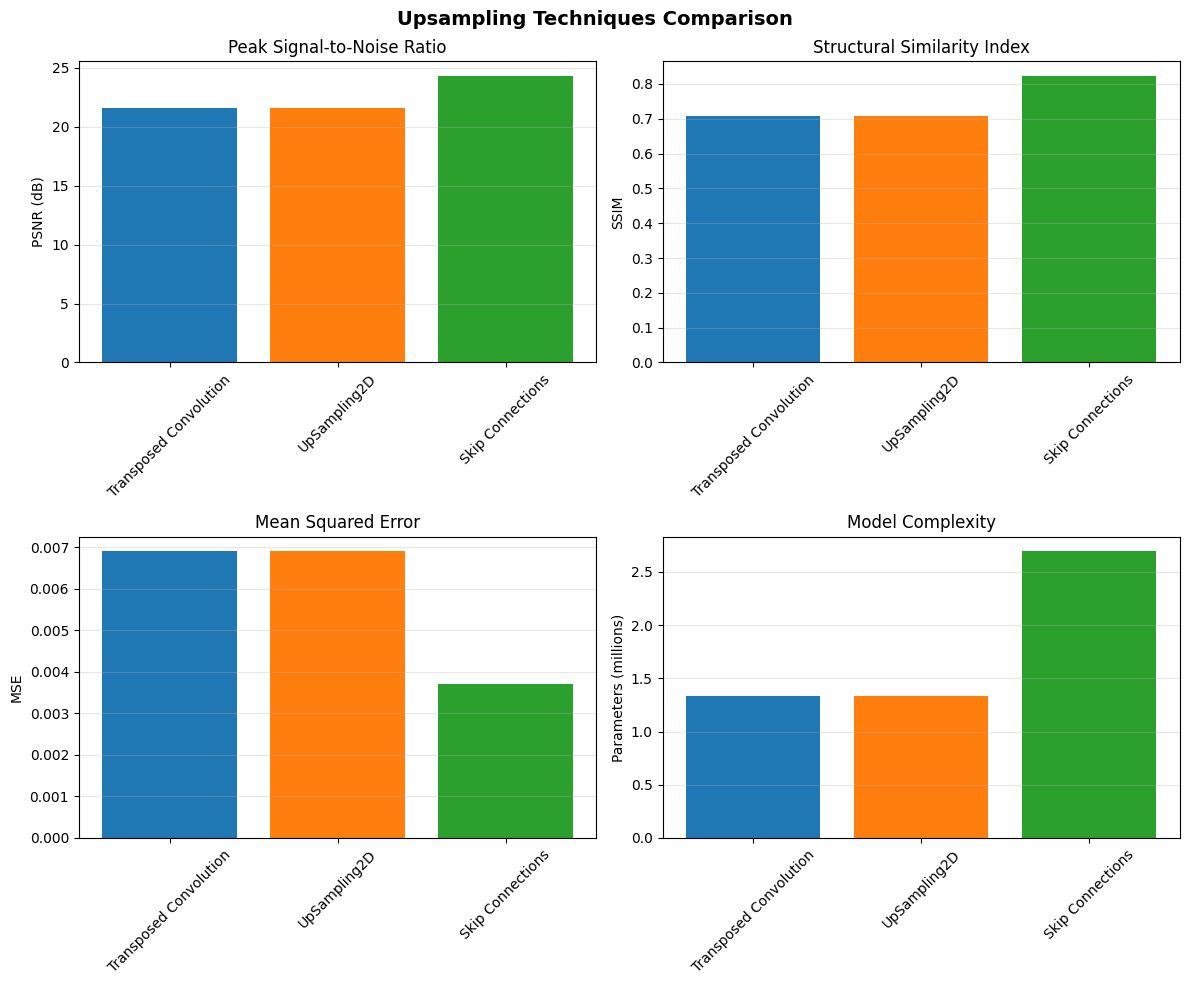


KEY FINDINGS:

1. Transposed Convolution:
   - Learnable upsampling with arbitrary kernels
   - Generally produces better reconstruction quality
   - Higher computational cost

2. UpSampling2D (Max Unpooling equivalent):
   - Simple nearest-neighbor or bilinear interpolation
   - Fewer parameters than transposed convolution
   - May produce checkerboard artifacts

3. Skip Connections:
   - Preserves fine details from encoder
   - Better gradient flow during training
   - Often produces best results despite higher parameters


In [13]:
# Comparison of upsampling techniques
comparison_data = {
    'Technique': ['Transposed Convolution', 'UpSampling2D', 'Skip Connections'],
    'Parameters': [
        dae_transposed.count_params(),
        dae_upsampling.count_params(),
        dae_skip.count_params()
    ],
    'PSNR': [
        evaluation_metrics['TransposedConv']['PSNR'],
        evaluation_metrics['UpSampling2D']['PSNR'],
        evaluation_metrics['SkipConnections']['PSNR']
    ],
    'SSIM': [
        evaluation_metrics['TransposedConv']['SSIM'],
        evaluation_metrics['UpSampling2D']['SSIM'],
        evaluation_metrics['SkipConnections']['SSIM']
    ],
    'MSE': [
        evaluation_metrics['TransposedConv']['MSE'],
        evaluation_metrics['UpSampling2D']['MSE'],
        evaluation_metrics['SkipConnections']['MSE']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nUPSAMPLING TECHNIQUES COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Upsampling Techniques Comparison', fontsize=14, fontweight='bold')

# PSNR
axes[0, 0].bar(comparison_df['Technique'], comparison_df['PSNR'], color=colors)
axes[0, 0].set_ylabel('PSNR (dB)')
axes[0, 0].set_title('Peak Signal-to-Noise Ratio')
axes[0, 0].tick_params(axis='x', rotation=45)

# SSIM
axes[0, 1].bar(comparison_df['Technique'], comparison_df['SSIM'], color=colors)
axes[0, 1].set_ylabel('SSIM')
axes[0, 1].set_title('Structural Similarity Index')
axes[0, 1].tick_params(axis='x', rotation=45)

# MSE
axes[1, 0].bar(comparison_df['Technique'], comparison_df['MSE'], color=colors)
axes[1, 0].set_ylabel('MSE')
axes[1, 0].set_title('Mean Squared Error')
axes[1, 0].tick_params(axis='x', rotation=45)

# Parameters
axes[1, 1].bar(comparison_df['Technique'], comparison_df['Parameters']/1e6, color=colors)
axes[1, 1].set_ylabel('Parameters (millions)')
axes[1, 1].set_title('Model Complexity')
axes[1, 1].tick_params(axis='x', rotation=45)

for ax in axes.flat:
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Key findings
print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)
print("\n1. Transposed Convolution:")
print("   - Learnable upsampling with arbitrary kernels")
print("   - Generally produces better reconstruction quality")
print("   - Higher computational cost")

print("\n2. UpSampling2D (Max Unpooling equivalent):")
print("   - Simple nearest-neighbor or bilinear interpolation")
print("   - Fewer parameters than transposed convolution")
print("   - May produce checkerboard artifacts")

print("\n3. Skip Connections:")
print("   - Preserves fine details from encoder")
print("   - Better gradient flow during training")
print("   - Often produces best results despite higher parameters")

## 10. Address Limited Annotated Data

### Strategies for Handling Limited Ground Truth


* **Synthetic data generation:** Create noisy-clean image pairs by adding artificial noise (Gaussian, salt-and-pepper, etc.) to clean images for supervised training.

* **Self-supervised learning:** Train without clean labels using methods like:

  * Noise2Noise (noisy-to-noisy training)
  * Noise2Void / Noise2Self (predict missing pixels from context)

* **Transfer learning:** Pretrain encoder on large datasets (e.g., ImageNet) or related tasks, then fine-tune on limited denoising data.

* **Data augmentation:** Increase dataset diversity using transformations like rotation, flipping, cropping, and multiple noise injections.

* **Semi-supervised learning:** Combine small labeled datasets with large unlabeled data using pseudo-labeling or consistency regularization.

* **Generative models (GAN-based):** Use GANs to generate realistic denoised outputs with sharper details.

* **Prior-based constraints:** Apply image priors like smoothness or regularization (e.g., total variation loss) to improve reconstruction quality with limited data.
